In [1]:
import time
print(time.ctime(time.time()))

Wed Mar 26 08:15:50 2025


In [2]:
import os
import cmocean
import pickle

import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import numpy as np
import pandas as pd
import xarray as xr

from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from glob import glob
from matplotlib.lines import Line2D
from matplotlib.ticker import FormatStrFormatter
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from pathlib import Path
from tqdm import tqdm

# Set Paths

In [3]:
# Set paths for main directories
# Main path
path_main = Path(os.path.abspath('')).parent.parent.parent
print(path_main)
# Working path
path_work = Path(os.path.abspath(''))
print(path_work)
# Files path
path_files = os.path.join(path_work,'files')


/Users/tarry/SCIENCE/git/FaSt-SWOT
/Users/tarry/SCIENCE/git/FaSt-SWOT/code/data_analysis/drifter_DKP


# Open all files, eliminate redundat data and unify

In [4]:
file_list = sorted(glob(os.path.join(path_files,'LS','leg2_n5','*')))
file_list[:5]

['/Users/tarry/SCIENCE/git/FaSt-SWOT/code/data_analysis/drifter_DKP/files/LS/leg2_n5/dkp_fast-SWOT_leg2_n5_000_20230510T0600.parquet',
 '/Users/tarry/SCIENCE/git/FaSt-SWOT/code/data_analysis/drifter_DKP/files/LS/leg2_n5/dkp_fast-SWOT_leg2_n5_001_20230510T0700.parquet',
 '/Users/tarry/SCIENCE/git/FaSt-SWOT/code/data_analysis/drifter_DKP/files/LS/leg2_n5/dkp_fast-SWOT_leg2_n5_002_20230510T0800.parquet',
 '/Users/tarry/SCIENCE/git/FaSt-SWOT/code/data_analysis/drifter_DKP/files/LS/leg2_n5/dkp_fast-SWOT_leg2_n5_003_20230510T0900.parquet',
 '/Users/tarry/SCIENCE/git/FaSt-SWOT/code/data_analysis/drifter_DKP/files/LS/leg2_n5/dkp_fast-SWOT_leg2_n5_004_20230510T1000.parquet']

In [5]:
df_all = pd.DataFrame()
for i,ifile in enumerate(file_list[:25]):
    df = pd.read_parquet(ifile, engine='pyarrow')
    # Select variables
    df_var = df[['aspect','length','divs','vort','strain','lat','lon']].copy()
    # Concatenate dataframes
    df_all = pd.concat([df_all,df_var])
df_all

,aspect,length,divs,vort,strain,lat,lon
0,0.080793,38.270225,-0.030490,-0.148190,0.099032,39.913675,1.391715
1,0.116707,35.759763,-0.055325,-0.068505,0.031409,39.979990,1.337216
2,0.053267,42.688610,-0.035038,-0.078953,0.077342,39.889718,1.403207
3,0.059475,41.034495,-0.024234,-0.086792,0.043508,39.885192,1.376949
4,0.059574,39.737544,-0.048429,-0.107971,0.048249,39.892992,1.377466
...,...,...,...,...,...,...,...
118750,0.419327,6.398159,0.223212,0.295497,0.407539,39.641914,1.259084
118751,0.338616,7.292988,0.159615,0.325712,0.339670,39.643261,1.267670
118752,0.255849,7.091590,0.166504,0.335645,0.358159,39.646706,1.268382
118753,0.158216,6.185789,0.263631,0.273297,0.454758,39.639424,1.281109


In [6]:
# Plot parameters
labelsz = 14
fontsz = 16

# Aspect ratio vs Length-scale binned maps

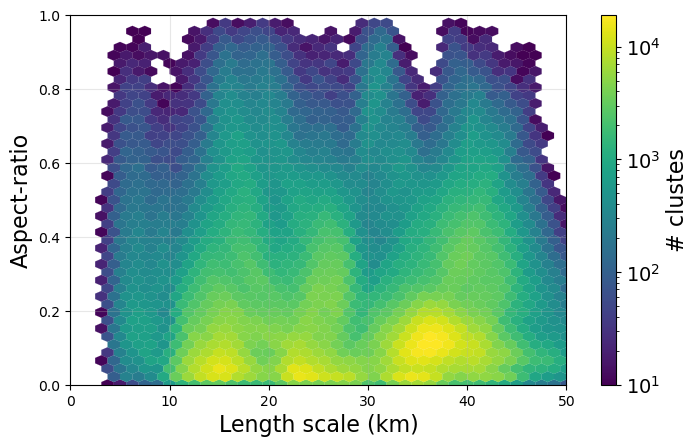

In [7]:
# Density plot
Lscale = 40
extent = [0,50,0,1]
xticks = np.arange(0,Lscale,5)
yticks = np.arange(0,2,0.2)

fig,ax = plt.subplots()

hb = ax.hexbin(df_all.length, df_all.aspect, 
            #C=df0.divs, 
            gridsize=Lscale, 
            #vmin=0, 
            #vmax=2e3+1, 
            cmap=mpl.cm.viridis, 
            bins='log', 
            mincnt=10, 
            linewidths=0.1, 
            extent=extent,
            zorder=1,
            )
#ax.plot([-1,40],[0.1,0.1],'k',linewidth=1.5,alpha=0.6,zorder=3)
ax.grid(alpha=0.3)

ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

ax.set_xlabel(r'Length scale (km)',fontsize=fontsz)
ax.set_ylabel(r'Aspect-ratio',fontsize=fontsz)

cbar_ax = inset_axes(ax, 
    width='3%', 
    height='100%', 
    loc='lower right', 
    bbox_to_anchor=(0.1,0,1,1), 
    bbox_transform=ax.transAxes, 
    borderpad=0)
cbar = fig.colorbar(hb, 
    cax=cbar_ax, 
    orientation='vertical', 
    #extend='both',
    #ticks=np.arange(-2,2,0.5)
    )
cbar.ax.set_ylabel(r'# clustes', fontsize=fontsz)
cbar.ax.tick_params(labelsize=labelsz)   

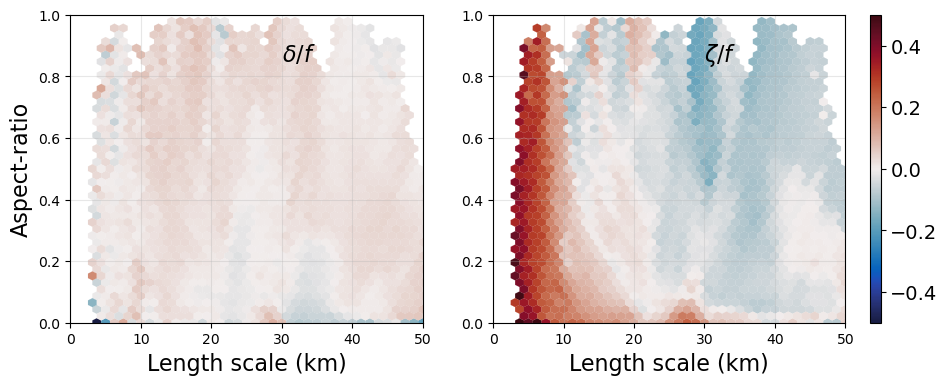

In [8]:
# Divergence and Vorticity plot
Lscale = 40
extent = [0,50,0,1]
xticks = np.arange(0,Lscale,5)
yticks = np.arange(0,2,0.2)

vmin = -0.5
vmax = 0.5

fig,axs = plt.subplots(ncols=2,figsize=(10,4))

ax = axs[0]

hb = ax.hexbin(df_all.length, df_all.aspect, 
            C=df_all.divs, 
            gridsize=Lscale, 
            vmin=vmin, 
            vmax=vmax, 
            cmap=cmocean.cm.balance, 
            #bins='log', 
            mincnt=10, 
            linewidths=0.1, 
            extent=extent,        
            reduce_C_function=np.median, 
            zorder=1,
            )
#ax.plot([-1,40],[0.1,0.1],'k',linewidth=1.5,alpha=0.6,zorder=3)
ax.grid(alpha=0.3)

ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

ax.set_xlabel(r'Length scale (km)',fontsize=fontsz)
ax.set_ylabel(r'Aspect-ratio',fontsize=fontsz)

ax.text(30,0.85,r'$\delta/f$',fontsize=fontsz)

ax = axs[1]
hb = ax.hexbin(df_all.length, df_all.aspect, 
            C=df_all.vort, 
            gridsize=Lscale, 
            vmin=vmin, 
            vmax=vmax, 
            cmap=cmocean.cm.balance, 
            #bins='log', 
            mincnt=10, 
            linewidths=0.1, 
            extent=extent,        
            reduce_C_function=np.median, 
            zorder=1,
            )
#ax.plot([-1,40],[0.1,0.1],'k',linewidth=1.5,alpha=0.6,zorder=3)
ax.grid(alpha=0.3)

ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

ax.set_xlabel(r'Length scale (km)',fontsize=fontsz)

ax.text(30,0.85,r'$\zeta/f$',fontsize=fontsz)


cbar_ax = inset_axes(ax, 
    width='3%', 
    height='100%', 
    loc='lower right', 
    bbox_to_anchor=(0.1,0,1,1), 
    bbox_transform=ax.transAxes, 
    borderpad=0)
cbar = fig.colorbar(hb, 
    cax=cbar_ax, 
    orientation='vertical', 
    #extend='both',
    #ticks=np.arange(-2,2,0.5)
    )
#cbar.ax.set_ylabel(r'$\delta/f$', fontsize=fontsz)
cbar.ax.tick_params(labelsize=labelsz)   

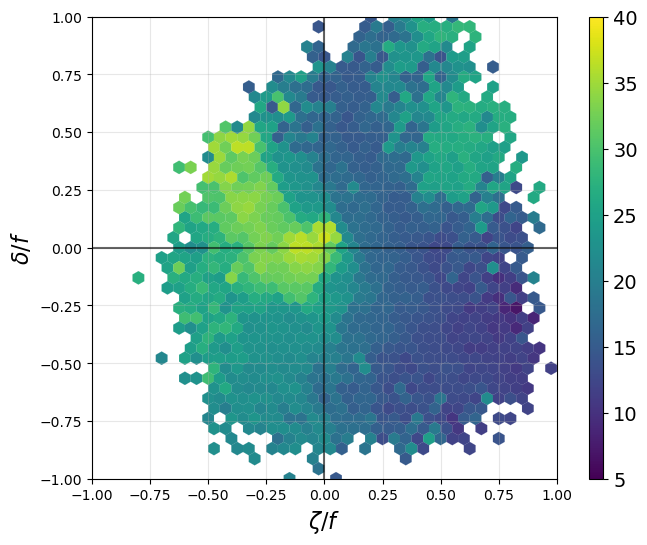

In [9]:
# Divergence and Vorticity plot
Lscale = 40
extent = [-1,1,-1,1]
xticks = np.arange(0,Lscale,5)
yticks = np.arange(0,2,0.2)

vmin = 5
vmax = 40

fig,ax = plt.subplots(figsize=(6,6))

ax

hb = ax.hexbin(df_all.vort, df_all.divs, 
            C=df_all.length, 
            gridsize=Lscale, 
            vmin=vmin, 
            vmax=vmax, 
            cmap=mpl.cm.viridis, 
            #bins='log', 
            mincnt=10, 
            linewidths=0.1, 
            extent=extent,        
            reduce_C_function=np.median, 
            zorder=1,
            )
ax.plot([0,0],[-1,1],'k',linewidth=1.5,alpha=0.6,zorder=3)
ax.plot([-1,1],[0,0],'k',linewidth=1.5,alpha=0.6,zorder=3)
ax.grid(alpha=0.3)

ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

ax.set_xlabel(r'$\zeta/f$',fontsize=fontsz)
ax.set_ylabel(r'$\delta/f$',fontsize=fontsz)


cbar_ax = inset_axes(ax, 
    width='3%', 
    height='100%', 
    loc='lower right', 
    bbox_to_anchor=(0.1,0,1,1), 
    bbox_transform=ax.transAxes, 
    borderpad=0)
cbar = fig.colorbar(hb, 
    cax=cbar_ax, 
    orientation='vertical', 
    #extend='both',
    #ticks=np.arange(-2,2,0.5)
    )
#cbar.ax.set_ylabel(r'$\delta/f$', fontsize=fontsz)
cbar.ax.tick_params(labelsize=labelsz)   

In [10]:
from mpl_toolkits.mplot3d import axes3d

In [11]:
# %matplotlib widget

# fig = plt.figure()
# ax = fig.add_subplot(111, projection='3d')
# ax.scatter(df_all.vort,df_all.divs,df_all.length)

# ax.set_xlim([-1,1])
# ax.set_ylim([-1,1])
# ax.set_zlim([0,50])

# plt.show()

### Remove bad alpha clusters

In [12]:
df_filt = df_all[df_all.aspect>0.1]
df_filt_lt_10km = df_filt[df_filt.length<10]
df_filt_gt_10km = df_filt[df_filt.length>10]

# Histograms of Divergence, Vorticity and Strain

### All scales

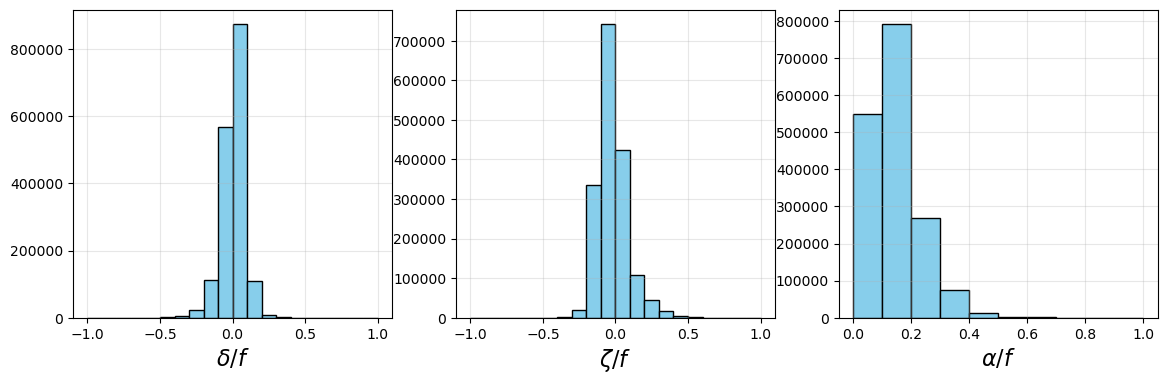

In [13]:
# Histogram plot parameters
hres = 0.1
hdmax = 1
hdmin = -hdmax
hvmax = 1
hvmin = -hvmax

fig,axs = plt.subplots(nrows=1,ncols=3,figsize=(14,4))

ax = axs[0]
(n,bins,patches) = ax.hist(df_filt.divs, 
    bins=np.arange(-hdmax,hdmax+hres,hres), 
    #density=True, 
    stacked=False,
    color='skyblue',
    edgecolor='k')
ax.set_xlabel(r'$\delta/f$',fontsize=fontsz)
ax.grid(alpha=0.3)

ax = axs[1]
(n,bins,patches) = ax.hist(df_filt.vort, 
    bins=np.arange(-hdmax,hdmax+hres,hres), 
    #density=True, 
    stacked=False,
    color='skyblue',
    edgecolor='k')
ax.set_xlabel(r'$\zeta/f$',fontsize=fontsz)
ax.grid(alpha=0.3)

ax = axs[2]
(n,bins,patches) = ax.hist(df_filt.strain, 
    bins=np.arange(0,hdmax+hres,hres), 
    #density=True, 
    stacked=False,
    color='skyblue',
    edgecolor='k')
ax.set_xlabel(r'$\alpha/f$',fontsize=fontsz)
ax.grid(alpha=0.3)


### Clusters below 10km

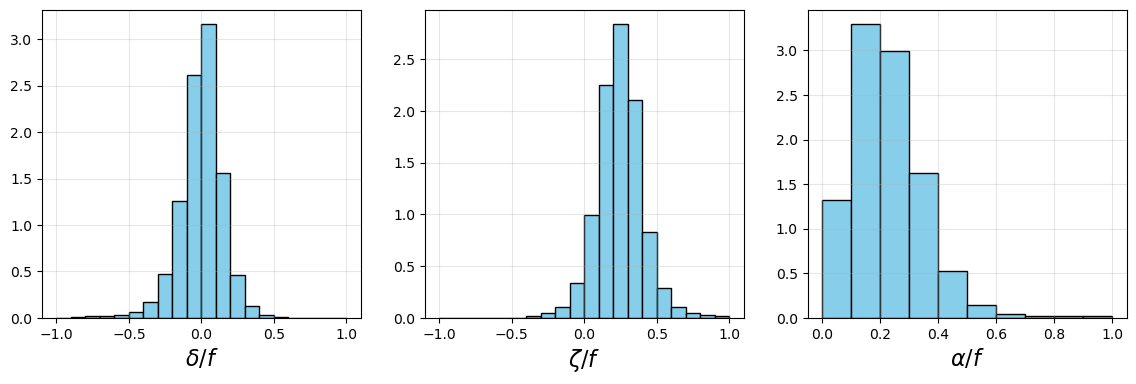

In [14]:
# Histogram plot parameters
hres = 0.1
hdmax = 1
hdmin = -hdmax
hvmax = 1
hvmin = -hvmax

fig,axs = plt.subplots(nrows=1,ncols=3,figsize=(14,4))

ax = axs[0]
(n,bins,patches) = ax.hist(df_filt_lt_10km.divs, 
    bins=np.arange(-hdmax,hdmax+hres,hres), 
    density=True, 
    stacked=False,
    color='skyblue',
    edgecolor='k')
ax.set_xlabel(r'$\delta/f$',fontsize=fontsz)
ax.grid(alpha=0.3)

ax = axs[1]
(n,bins,patches) = ax.hist(df_filt_lt_10km.vort, 
    bins=np.arange(-hdmax,hdmax+hres,hres), 
    density=True, 
    stacked=False,
    color='skyblue',
    edgecolor='k')
ax.set_xlabel(r'$\zeta/f$',fontsize=fontsz)
ax.grid(alpha=0.3)

ax = axs[2]
(n,bins,patches) = ax.hist(df_filt_lt_10km.strain, 
    bins=np.arange(0,hdmax+hres,hres), 
    density=True, 
    stacked=False,
    color='skyblue',
    edgecolor='k')
ax.set_xlabel(r'$\alpha/f$',fontsize=fontsz)
ax.grid(alpha=0.3)


### Clusters larger than 10km

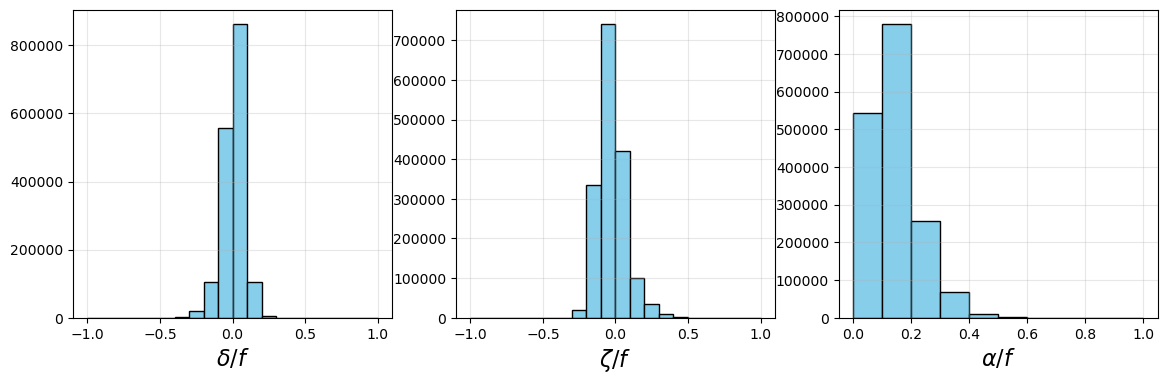

In [15]:
# Histogram plot parameters
hres = 0.1
hdmax = 1
hdmin = -hdmax
hvmax = 1
hvmin = -hvmax

fig,axs = plt.subplots(nrows=1,ncols=3,figsize=(14,4))

ax = axs[0]
(n,bins,patches) = ax.hist(df_filt_gt_10km.divs, 
    bins=np.arange(-hdmax,hdmax+hres,hres), 
    #density=True, 
    stacked=False,
    color='skyblue',
    edgecolor='k')
ax.set_xlabel(r'$\delta/f$',fontsize=fontsz)
ax.grid(alpha=0.3)

ax = axs[1]
(n,bins,patches) = ax.hist(df_filt_gt_10km.vort, 
    bins=np.arange(-hdmax,hdmax+hres,hres), 
    #density=True, 
    stacked=False,
    color='skyblue',
    edgecolor='k')
ax.set_xlabel(r'$\zeta/f$',fontsize=fontsz)
ax.grid(alpha=0.3)

ax = axs[2]
(n,bins,patches) = ax.hist(df_filt_gt_10km.strain, 
    bins=np.arange(0,hdmax+hres,hres), 
    #density=True, 
    stacked=False,
    color='skyblue',
    edgecolor='k')
ax.set_xlabel(r'$\alpha/f$',fontsize=fontsz)
ax.grid(alpha=0.3)


# Divergence on Vorticity-Strain space

### All scales

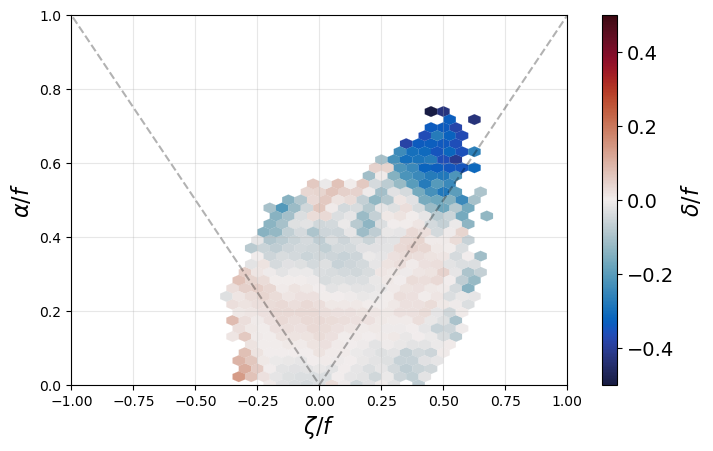

In [16]:
# Density plot
Lscale = 40
extent = [-1,1,0,1]
#xticks = np.arange(0,Lscale,5)
#yticks = np.arange(0,2,0.2)

fig,ax = plt.subplots()

hb = ax.hexbin(df_filt.vort, df_filt.strain, 
            C=df_filt.divs, 
            gridsize=Lscale, 
            vmin=-0.5, 
            vmax=0.5, 
            cmap=cmocean.cm.balance, 
            bins=None, 
            mincnt=10, 
            linewidths=0.1, 
            extent=extent,
            zorder=1,
            )
#ax.plot([-1,40],[0.1,0.1],'k',linewidth=1.5,alpha=0.6,zorder=3)
ax.grid(alpha=0.3)

ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

ax.set_xlabel(r'$\zeta/f$',fontsize=fontsz)
ax.set_ylabel(r'$\alpha/f$',fontsize=fontsz)

cbar_ax = inset_axes(ax, 
    width='3%', 
    height='100%', 
    loc='lower right', 
    bbox_to_anchor=(0.1,0,1,1), 
    bbox_transform=ax.transAxes, 
    borderpad=0)
cbar = fig.colorbar(hb, 
    cax=cbar_ax, 
    orientation='vertical', 
    #extend='both',
    #ticks=np.arange(-2,2,0.5)
    )
cbar.ax.set_ylabel(r'$\delta/f$', fontsize=fontsz)
cbar.ax.tick_params(labelsize=labelsz)   

guide_x = np.linspace(-10,10,101)
guide_y = np.abs(guide_x)
ax.plot(guide_x,guide_y,'k',ls='--',lw=1.5,alpha=0.3)

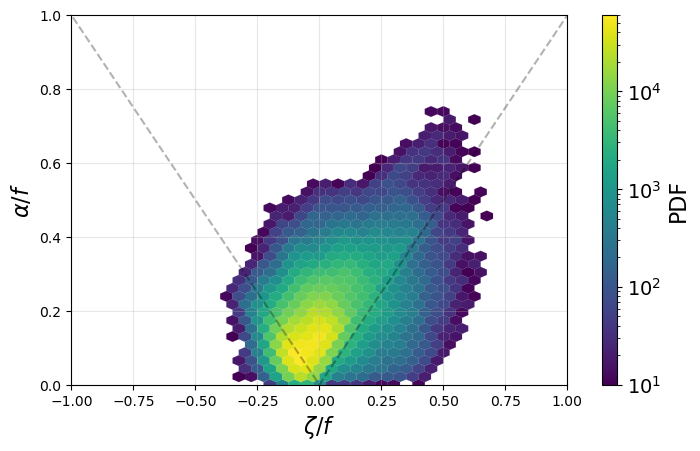

In [17]:
# Density plot
Lscale = 40
extent = [-1,1,0,1]
#xticks = np.arange(0,Lscale,5)
#yticks = np.arange(0,2,0.2)

fig,ax = plt.subplots()

hb = ax.hexbin(df_filt.vort, df_filt.strain, 
            # C=df_filt.divs, 
            gridsize=Lscale, 
            # vmin=-0.5, 
            # vmax=0.5, 
            cmap=mpl.cm.viridis, 
            bins='log', 
            mincnt=10, 
            linewidths=0.1, 
            extent=extent,
            zorder=1,
            )
#ax.plot([-1,40],[0.1,0.1],'k',linewidth=1.5,alpha=0.6,zorder=3)
ax.grid(alpha=0.3)

ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

ax.set_xlabel(r'$\zeta/f$',fontsize=fontsz)
ax.set_ylabel(r'$\alpha/f$',fontsize=fontsz)

cbar_ax = inset_axes(ax, 
    width='3%', 
    height='100%', 
    loc='lower right', 
    bbox_to_anchor=(0.1,0,1,1), 
    bbox_transform=ax.transAxes, 
    borderpad=0)
cbar = fig.colorbar(hb, 
    cax=cbar_ax, 
    orientation='vertical', 
    #extend='both',
    #ticks=np.arange(-2,2,0.5)
    )
cbar.ax.set_ylabel(r'PDF', fontsize=fontsz)
cbar.ax.tick_params(labelsize=labelsz)   

guide_x = np.linspace(-10,10,101)
guide_y = np.abs(guide_x)
ax.plot(guide_x,guide_y,'k',ls='--',lw=1.5,alpha=0.3)

### Clusters below 10km

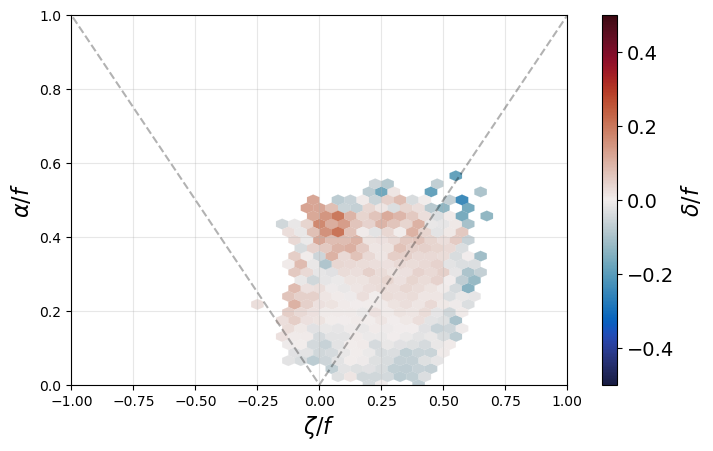

In [28]:
# Density plot
Lscale = 40
extent = [-1,1,0,1]
#xticks = np.arange(0,Lscale,5)
#yticks = np.arange(0,2,0.2)

fig,ax = plt.subplots()

hb = ax.hexbin(df_filt_lt_10km.vort, df_filt_lt_10km.strain, 
            C=df_filt_lt_10km.divs, 
            gridsize=Lscale, 
            vmin=-0.5, 
            vmax=0.5, 
            cmap=cmocean.cm.balance, 
            bins=None, 
            mincnt=10, 
            linewidths=0.1, 
            extent=extent,
            zorder=1,
            )
#ax.plot([-1,40],[0.1,0.1],'k',linewidth=1.5,alpha=0.6,zorder=3)
ax.grid(alpha=0.3)

ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

ax.set_xlabel(r'$\zeta/f$',fontsize=fontsz)
ax.set_ylabel(r'$\alpha/f$',fontsize=fontsz)

cbar_ax = inset_axes(ax, 
    width='3%', 
    height='100%', 
    loc='lower right', 
    bbox_to_anchor=(0.1,0,1,1), 
    bbox_transform=ax.transAxes, 
    borderpad=0)
cbar = fig.colorbar(hb, 
    cax=cbar_ax, 
    orientation='vertical', 
    #extend='both',
    #ticks=np.arange(-2,2,0.5)
    )
cbar.ax.set_ylabel(r'$\delta/f$', fontsize=fontsz)
cbar.ax.tick_params(labelsize=labelsz)   

guide_x = np.linspace(-10,10,101)
guide_y = np.abs(guide_x)
ax.plot(guide_x,guide_y,'k',ls='--',lw=1.5,alpha=0.3)

# Binned Maps

In [29]:
# Load drifter data
fname = 'drifters_DKP_Leg2.parquet'
fpath = os.path.join(path_files,fname)
df_drifter = pd.read_parquet(fpath, engine='pyarrow')

In [30]:
# Set range of time
t1 = pd.Timestamp(2023,5,10,6)
t2 = pd.Timestamp(2023,5,15,6)

In [31]:
# Subset the df
df_drifters = df_drifter[(df_drifter.index>=t1) & (df_drifter.index<=t2)]


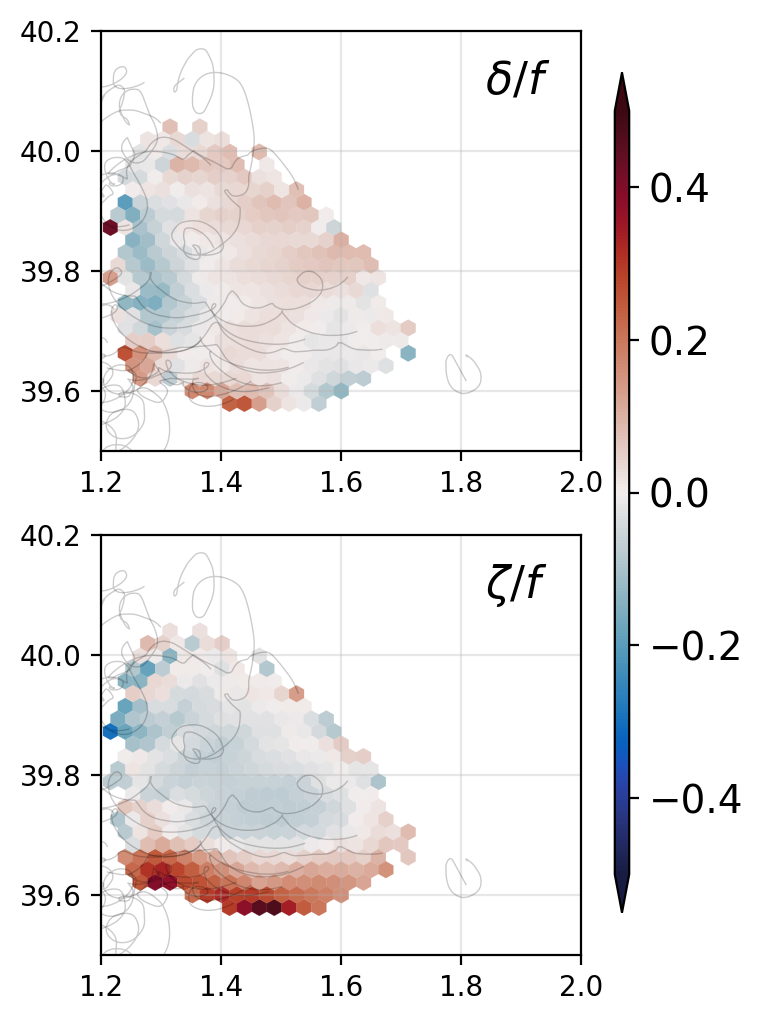

In [34]:
# Divergence and Vortcity with drifters
Lscale = 20
extent = [1.2, 2, 39.5, 40.2]
#xticks = np.arange(-10,10,0.25)
#yticks = np.arange(-10,10,0.25)

vmin = -0.5
vmax = 0.5

fig,axs = plt.subplots(nrows=2,figsize=(6,6),dpi=200)

ax = axs[0]
hb = ax.hexbin(df_all.lon, df_all.lat, 
    C=df_all.divs, 
    gridsize=Lscale, 
    vmin=vmin, 
    vmax=vmax, 
    cmap=cmocean.cm.balance, 
    #bins=None, 
    mincnt=5, 
    reduce_C_function=np.median, 
    linewidths=0.1, 
    #extent=extent
    )
for i in range(20):
    drifter = df_drifters[df_drifters['i']==i]
    ax.plot(drifter['LON'],drifter['LAT'],c='k',lw=0.5,alpha=0.2)
ax.grid(alpha=0.3)
ax.set_aspect('equal')
ax.text(0.8,0.85,r'$\delta/f$',fontsize=fontsz,transform=ax.transAxes)

ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

ax = axs[1]
hb = ax.hexbin(df_all.lon, df_all.lat, 
    C=df_all.vort, 
    gridsize=Lscale, 
    vmin=vmin, 
    vmax=vmax, 
    cmap=cmocean.cm.balance, 
    #bins=None, 
    mincnt=5, 
    reduce_C_function=np.median, 
    linewidths=0.1, 
    #extent=extent
    )
for i in range(20):
    drifter = df_drifters[df_drifters['i']==i]
    ax.plot(drifter['LON'],drifter['LAT'],c='k',lw=0.5,alpha=0.2)
#ax.plot([-1,40],[0.1,0.1],'k',linewidth=1.5,alpha=0.6,zorder=3)
ax.grid(alpha=0.3)
ax.set_aspect('equal')
ax.text(0.8,0.85,r'$\zeta/f$',fontsize=fontsz,transform=ax.transAxes)

ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

cbar_ax = inset_axes(ax, 
    width='3%', 
    height='200%', 
    loc='lower right', 
    bbox_to_anchor=(0.1,0.1,1,1), 
    bbox_transform=ax.transAxes, 
    borderpad=0)
cbar = fig.colorbar(hb, 
    cax=cbar_ax, 
    orientation='vertical', 
    extend='both',
    #ticks=np.arange(-2,2,0.5)
    )
#cbar.ax.set_ylabel(r'$\delta/f$', fontsize=fontsz)
cbar.ax.tick_params(labelsize=labelsz)  

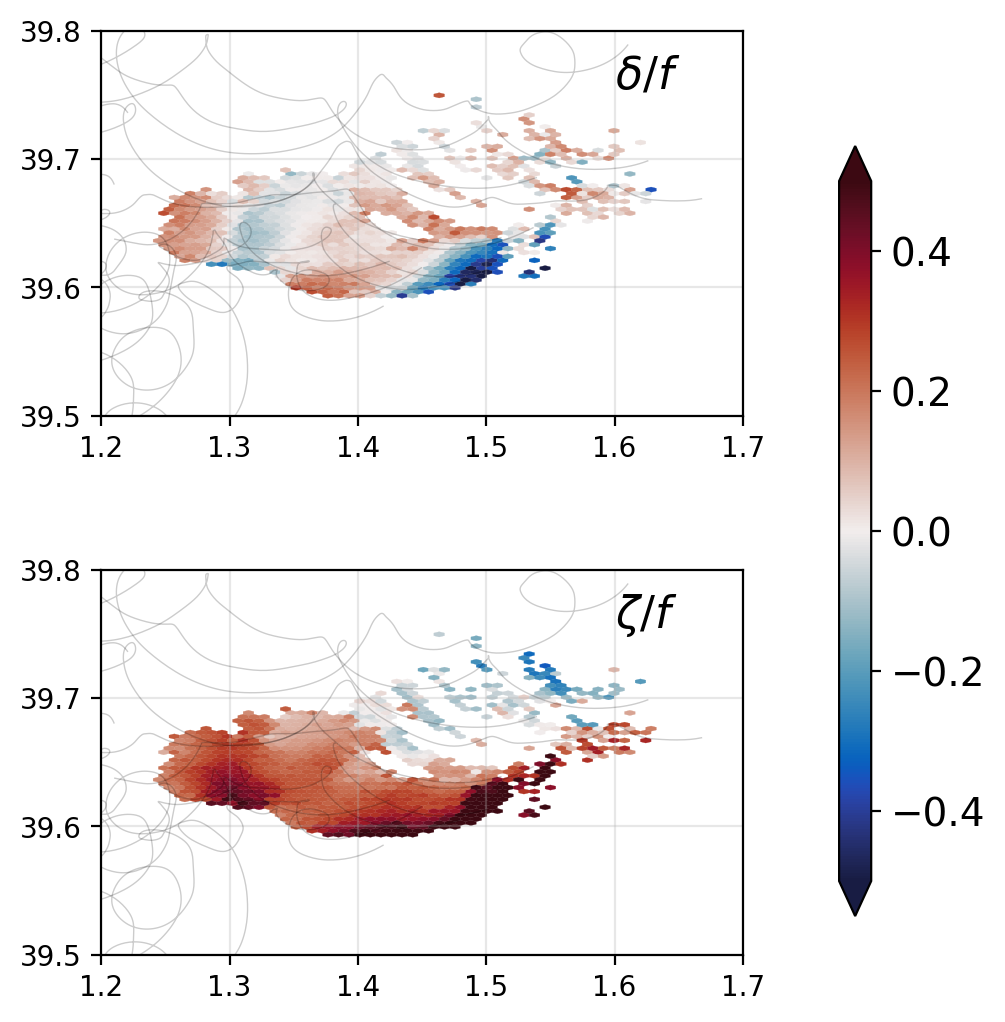

In [51]:
# Divergence and Vortcity with drifters
Lscale = 50
extent = [1.2, 1.7, 39.5, 39.8]
#xticks = np.arange(-10,10,0.25)
#yticks = np.arange(-10,10,0.25)

vmin = -0.5
vmax = 0.5

fig,axs = plt.subplots(nrows=2,figsize=(6,6),dpi=200)

ax = axs[0]
hb = ax.hexbin(df_filt_lt_10km.lon, df_filt_lt_10km.lat, 
    C=df_filt_lt_10km.divs, 
    gridsize=Lscale, 
    vmin=vmin, 
    vmax=vmax, 
    cmap=cmocean.cm.balance, 
    #bins=None, 
    mincnt=3, 
    reduce_C_function=np.median, 
    linewidths=0.1, 
    #extent=extent
    )
for i in range(20):
    drifter = df_drifters[df_drifters['i']==i]
    ax.plot(drifter['LON'],drifter['LAT'],c='k',lw=0.5,alpha=0.2)
ax.grid(alpha=0.3)
ax.set_aspect('equal')
ax.text(0.8,0.85,r'$\delta/f$',fontsize=fontsz,transform=ax.transAxes)

ax.set_yticks(np.arange(1,100,0.1))
ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

ax = axs[1]
hb = ax.hexbin(df_filt_lt_10km.lon, df_filt_lt_10km.lat, 
    C=df_filt_lt_10km.vort, 
    gridsize=Lscale, 
    vmin=vmin, 
    vmax=vmax, 
    cmap=cmocean.cm.balance, 
    #bins=None, 
    mincnt=3, 
    reduce_C_function=np.median, 
    linewidths=0.1, 
    #extent=extent
    )
for i in range(20):
    drifter = df_drifters[df_drifters['i']==i]
    ax.plot(drifter['LON'],drifter['LAT'],c='k',lw=0.5,alpha=0.2)
#ax.plot([-1,40],[0.1,0.1],'k',linewidth=1.5,alpha=0.6,zorder=3)
ax.grid(alpha=0.3)
ax.set_aspect('equal')
ax.text(0.8,0.85,r'$\zeta/f$',fontsize=fontsz,transform=ax.transAxes)

ax.set_yticks(np.arange(1,100,0.1))
ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

cbar_ax = inset_axes(ax, 
    width='5%', 
    height='200%', 
    loc='lower right', 
    bbox_to_anchor=(0.2,0.1,1,1), 
    bbox_transform=ax.transAxes, 
    borderpad=0)
cbar = fig.colorbar(hb, 
    cax=cbar_ax, 
    orientation='vertical', 
    extend='both',
    #ticks=np.arange(-2,2,0.5)
    )
#cbar.ax.set_ylabel(r'$\delta/f$', fontsize=fontsz)
cbar.ax.tick_params(labelsize=labelsz)  

plt.subplots_adjust(hspace=0.4)

## Strong Convergence signal

In [23]:
# Remove positive divergence signal
df_conv  = df_all[df_all.divs<-0.3]

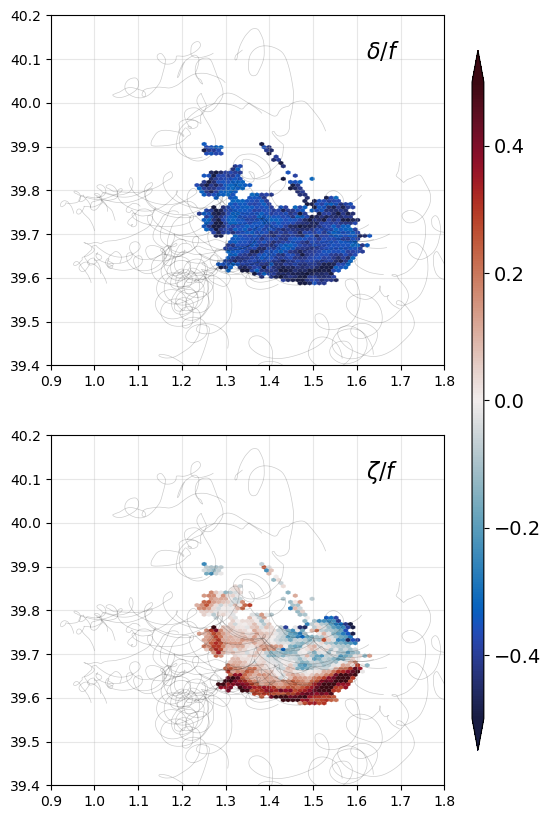

In [24]:
# Divergence and Vortcity with drifters
#Lscale = 40
extent = [0.9, 1.8, 39.4, 40.2]
#xticks = np.arange(-10,10,0.25)
#yticks = np.arange(-10,10,0.25)

vmin = -0.5
vmax = 0.5

fig,axs = plt.subplots(nrows=2,figsize=(10,10),dpi=100)

ax = axs[0]
hb = ax.hexbin(df_conv.lon, df_conv.lat, 
    C=df_conv.divs, 
    gridsize=Lscale, 
    vmin=vmin, 
    vmax=vmax, 
    cmap=cmocean.cm.balance, 
    #bins=None, 
    mincnt=5, 
    reduce_C_function=np.median, 
    linewidths=0.1, 
    #extent=extent
    )
for i in range(40):
    drifter = df_drifters[df_drifters['i']==i]
    ax.plot(drifter['LON'],drifter['LAT'],c='k',lw=0.5,alpha=0.2)
ax.grid(alpha=0.3)
ax.set_aspect('equal')
ax.text(1.62,40.1,r'$\delta/f$',fontsize=fontsz)

ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

ax = axs[1]
hb = ax.hexbin(df_conv.lon, df_conv.lat, 
    C=df_conv.vort, 
    gridsize=Lscale, 
    vmin=vmin, 
    vmax=vmax, 
    cmap=cmocean.cm.balance, 
    #bins=None, 
    mincnt=5, 
    reduce_C_function=np.median, 
    linewidths=0.1, 
    #extent=extent
    )
for i in range(40):
    drifter = df_drifters[df_drifters['i']==i]
    ax.plot(drifter['LON'],drifter['LAT'],c='k',lw=0.5,alpha=0.2)
#ax.plot([-1,40],[0.1,0.1],'k',linewidth=1.5,alpha=0.6,zorder=3)
ax.grid(alpha=0.3)
ax.set_aspect('equal')
ax.text(1.62,40.1,r'$\zeta/f$',fontsize=fontsz)

ax.set_xlim([extent[0],extent[1]])
ax.set_ylim([extent[2],extent[3]])

cbar_ax = inset_axes(ax, 
    width='3%', 
    height='200%', 
    loc='lower right', 
    bbox_to_anchor=(0.1,0.1,1,1), 
    bbox_transform=ax.transAxes, 
    borderpad=0)
cbar = fig.colorbar(hb, 
    cax=cbar_ax, 
    orientation='vertical', 
    extend='both',
    #ticks=np.arange(-2,2,0.5)
    )
#cbar.ax.set_ylabel(r'$\delta/f$', fontsize=fontsz)
cbar.ax.tick_params(labelsize=labelsz)  